Dataset Overview:
Shape: (850, 83)
First few column names: ['Unnamed: 0', 'Comment', 'Video Popularity', 'Comment Popularity', 'Gender of Sport_Female', 'Gender of Sport_Male', 'Club_Arsenal', 'Club_Bayern München', 'Club_Chelsea', 'Club_Club América', 'Club_Corinthians', 'Club_Juventus', 'Club_Manchester United', 'Club_Napoli', 'Club_Olympique Lyon']

Gender distribution:
gender_sport
Male      554
Female    296
Name: count, dtype: int64

Filtered data (known genders only): 850 rows
Gender distribution (filtered): {'Male': 554, 'Female': 296}
Overall hate rate: 3.65%

HATE SPEECH BY GENDER OF SPORT - KEY STATISTICS
              total_comments  hate_comments  hate_rate  sexism_count  \
gender_sport                                                           
Female                   296             14   0.047297             8   
Male                     554             17   0.030686             3   

              racism_count  violence_count  appearance_count  ability_count  
gender_sp

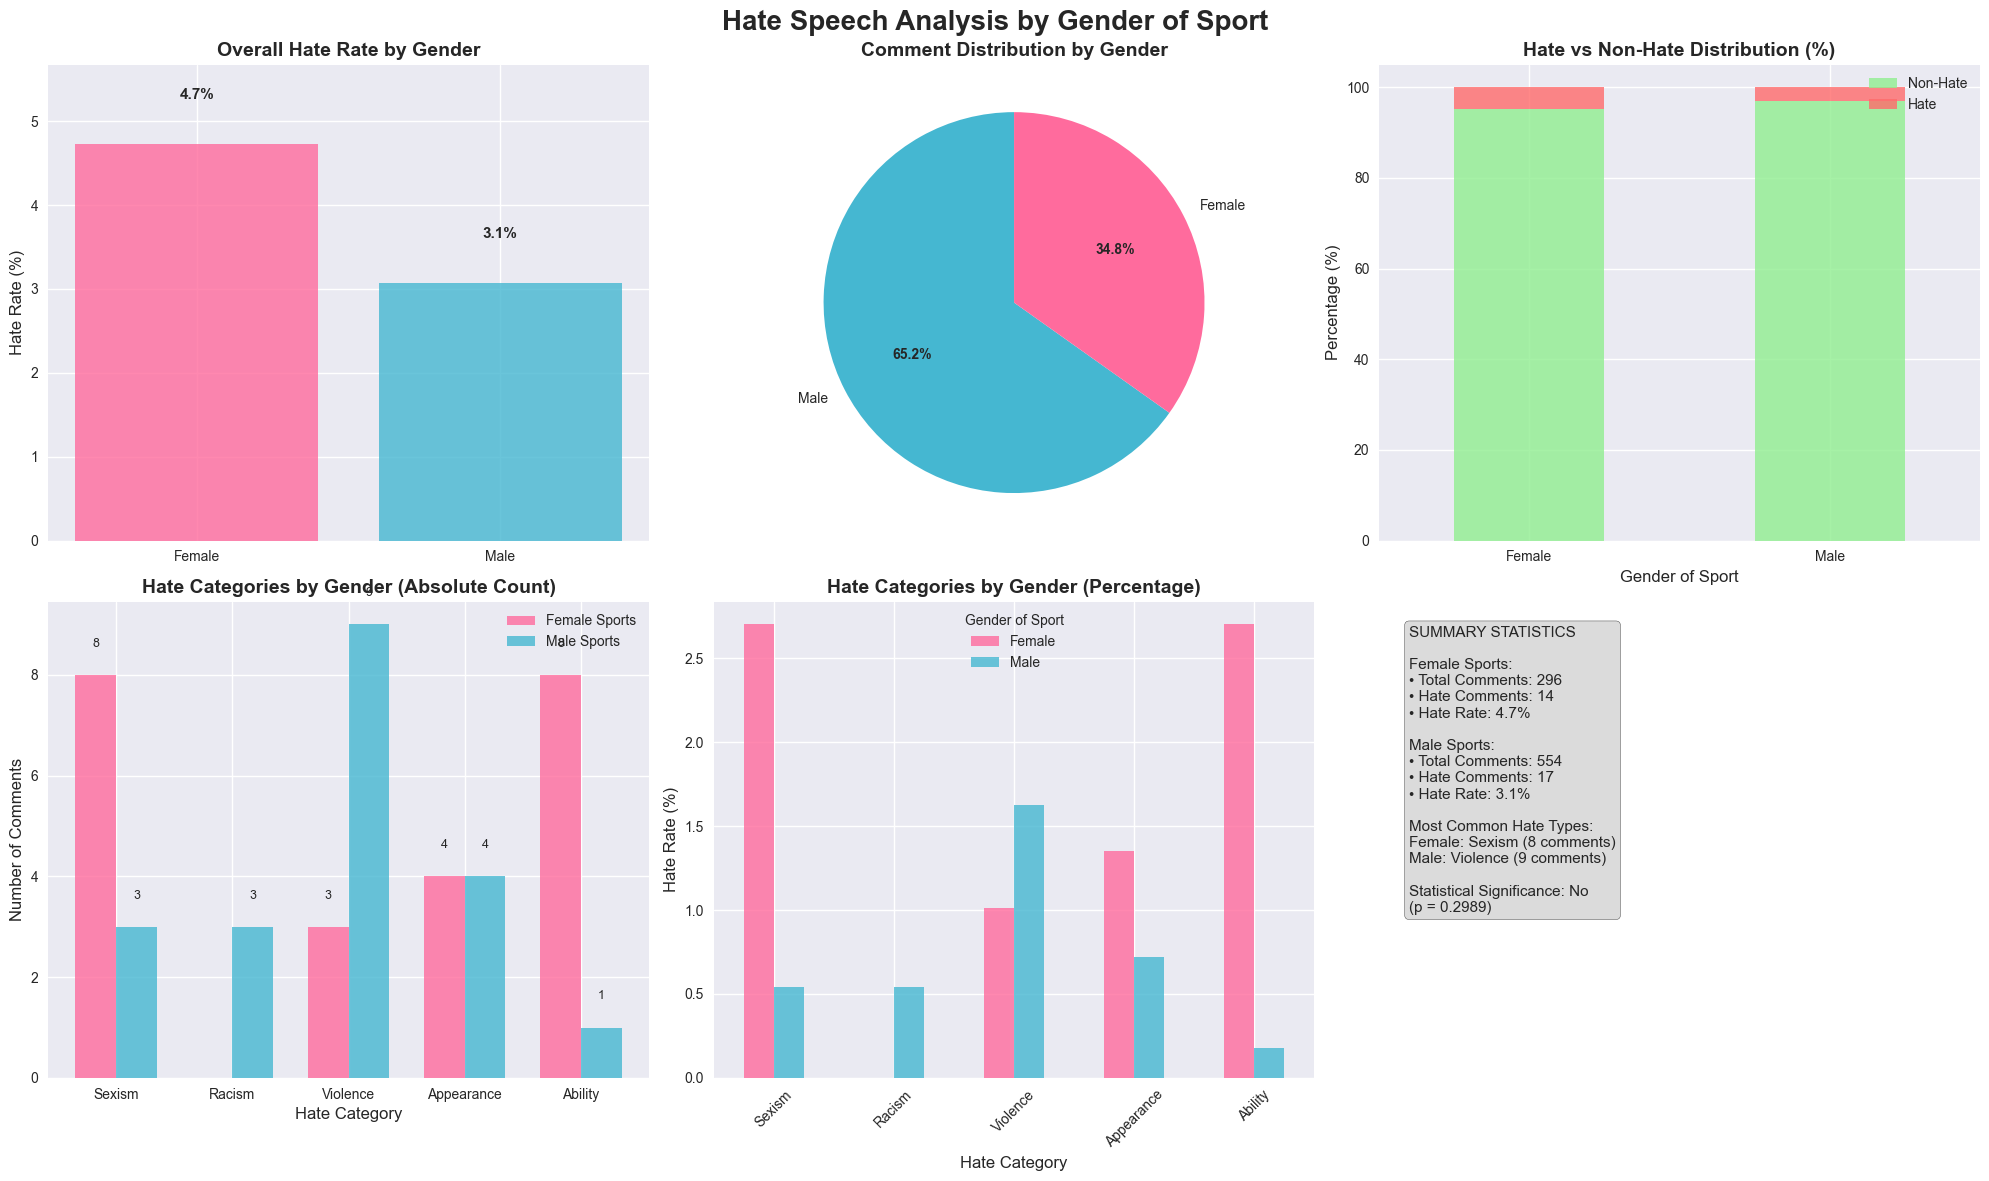

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('../Datasets/labeled_comments.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"First few column names: {df.columns.tolist()[:15]}")

# =============================================================================
# DIRECT DATA PROCESSING - NO COMPLEX REVERSE ENGINEERING
# =============================================================================

# 1. Extract Gender of Sport robustly
df['gender_sport'] = 'Unknown'

if 'Gender of Sport_Female' in df.columns:
    df.loc[df['Gender of Sport_Female'].astype(str).str.lower().isin(['true', '1']), 'gender_sport'] = 'Female'

if 'Gender of Sport_Male' in df.columns:
    df.loc[df['Gender of Sport_Male'].astype(str).str.lower().isin(['true', '1']), 'gender_sport'] = 'Male'

print(f"\nGender distribution:")
print(df['gender_sport'].value_counts())

# 2. Process hate categories directly - handle both empty strings and numeric values
def convert_hate_column(col_series):
    """Convert hate column to boolean, handling empty strings and numeric values"""
    result = []
    for val in col_series:
        if pd.isna(val) or val == '' or val == ' ':
            result.append(False)
        else:
            try:
                result.append(float(val) > 0)
            except (ValueError, TypeError):
                result.append(False)
    return result

# Apply to hate columns
hate_columns = ['Sexism', 'Racism', 'Violence', 'Appearance', 'Ability']
for col in hate_columns:
    if col in df.columns:
        df[f'{col.lower()}_hate'] = convert_hate_column(df[col])
    else:
        df[f'{col.lower()}_hate'] = False

# 3. Create overall hate indicator
df['any_hate'] = (df['sexism_hate'] | df['racism_hate'] | df['violence_hate'] | 
                  df['appearance_hate'] | df['ability_hate'])

# 4. Filter to only known genders
df_analysis = df[df['gender_sport'] != 'Unknown'].copy()

print(f"\nFiltered data (known genders only): {len(df_analysis)} rows")
print(f"Gender distribution (filtered): {df_analysis['gender_sport'].value_counts().to_dict()}")
print(f"Overall hate rate: {df_analysis['any_hate'].mean():.2%}")

# =============================================================================
# KEY STATISTICS
# =============================================================================

print("\n" + "="*60)
print("HATE SPEECH BY GENDER OF SPORT - KEY STATISTICS")
print("="*60)

# Calculate statistics by gender
if not df_analysis.empty:
    stats_by_gender = df_analysis.groupby('gender_sport').agg({
        'any_hate': ['count', 'sum', 'mean'],
        'sexism_hate': 'sum',
        'racism_hate': 'sum',
        'violence_hate': 'sum',
        'appearance_hate': 'sum',
        'ability_hate': 'sum'
    })

    # Flatten column names
    stats_by_gender.columns = ['total_comments', 'hate_comments', 'hate_rate',
                              'sexism_count', 'racism_count', 'violence_count',
                              'appearance_count', 'ability_count']

    print(stats_by_gender)

    # Statistical significance test
    if len(df_analysis['gender_sport'].unique()) >= 2:
        contingency = pd.crosstab(df_analysis['gender_sport'], df_analysis['any_hate'])
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        
        print(f"\n📊 Statistical Significance Test:")
        print(f"Chi-square: {chi2:.4f}")
        print(f"P-value: {p_value:.4f}")
        print(f"Significant: {'Yes' if p_value < 0.05 else 'No'} (α = 0.05)")
else:
    stats_by_gender = pd.DataFrame()
    print("⚠️ No gender-labeled data available for statistics.")

# =============================================================================
# MAIN VISUALIZATION: HATE BY GENDER WITH PERCENTAGES AND TYPES
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Hate Speech Analysis by Gender of Sport', fontsize=20, fontweight='bold', y=0.98)

# Define colors
colors = {'Female': '#FF6B9D', 'Male': '#45B7D1'}

# 1. Overall Hate Rate by Gender (Percentages)
hate_rates = df_analysis.groupby('gender_sport')['any_hate'].mean() * 100

if not hate_rates.empty:
    bars = axes[0,0].bar(hate_rates.index, hate_rates.values, 
                         color=[colors[gender] for gender in hate_rates.index], alpha=0.8)
    axes[0,0].set_title('Overall Hate Rate by Gender', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('Hate Rate (%)', fontsize=12)
    axes[0,0].set_ylim(0, max(hate_rates.values) * 1.2)

    for bar, value in zip(bars, hate_rates.values):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                       f'{value:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
else:
    axes[0,0].text(0.5, 0.5, "No gender-labeled data", ha='center', va='center', fontsize=12)
    axes[0,0].set_axis_off()

# 2. Total Comments Distribution
comment_counts = df_analysis['gender_sport'].value_counts()
if not comment_counts.empty:
    wedges, texts, autotexts = axes[0,1].pie(comment_counts.values, labels=comment_counts.index, 
                                              autopct='%1.1f%%', startangle=90,
                                              colors=[colors[gender] for gender in comment_counts.index])
    axes[0,1].set_title('Comment Distribution by Gender', fontsize=14, fontweight='bold')
    for autotext in autotexts:
        autotext.set_fontweight('bold')
else:
    axes[0,1].text(0.5, 0.5, "No data", ha='center', va='center', fontsize=12)
    axes[0,1].set_axis_off()

# 3. Hate vs Non-Hate Stacked Bar
if not df_analysis.empty:
    hate_cross = pd.crosstab(df_analysis['gender_sport'], df_analysis['any_hate'], normalize='index') * 100
    hate_cross.plot(kind='bar', stacked=True, ax=axes[0,2], 
                    color=['#90EE90', '#FF6B6B'], alpha=0.8)
    axes[0,2].set_title('Hate vs Non-Hate Distribution (%)', fontsize=14, fontweight='bold')
    axes[0,2].set_ylabel('Percentage (%)', fontsize=12)
    axes[0,2].set_xlabel('Gender of Sport', fontsize=12)
    axes[0,2].legend(['Non-Hate', 'Hate'], loc='upper right')
    axes[0,2].tick_params(axis='x', rotation=0)
else:
    axes[0,2].text(0.5, 0.5, "No data", ha='center', va='center', fontsize=12)
    axes[0,2].set_axis_off()

# 4. Hate Categories by Gender (Absolute Numbers)
hate_categories = ['sexism_count', 'racism_count', 'violence_count', 'appearance_count', 'ability_count']
category_labels = ['Sexism', 'Racism', 'Violence', 'Appearance', 'Ability']

x = np.arange(len(category_labels))
width = 0.35

if not stats_by_gender.empty:
    genders = stats_by_gender.index.tolist()
    if 'Female' in genders:
        bars1 = axes[1,0].bar(x - width/2, [stats_by_gender.loc['Female', cat] for cat in hate_categories], 
                             width, label='Female Sports', color=colors['Female'], alpha=0.8)
    if 'Male' in genders:
        bars2 = axes[1,0].bar(x + width/2, [stats_by_gender.loc['Male', cat] for cat in hate_categories], 
                             width, label='Male Sports', color=colors['Male'], alpha=0.8)

    axes[1,0].set_title('Hate Categories by Gender (Absolute Count)', fontsize=14, fontweight='bold')
    axes[1,0].set_ylabel('Number of Comments', fontsize=12)
    axes[1,0].set_xlabel('Hate Category', fontsize=12)
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels(category_labels)
    axes[1,0].legend()

    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                axes[1,0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                              f'{int(height)}', ha='center', va='bottom', fontsize=9)

    if 'Female' in genders:
        add_labels(bars1)
    if 'Male' in genders:
        add_labels(bars2)
else:
    axes[1,0].text(0.5, 0.5, "No data", ha='center', va='center', fontsize=12)
    axes[1,0].set_axis_off()

# 5. Hate Categories by Gender (Percentages)
if not df_analysis.empty:
    hate_rates_by_cat = df_analysis.groupby('gender_sport')[['sexism_hate', 'racism_hate', 'violence_hate', 
                                                            'appearance_hate', 'ability_hate']].mean() * 100

    hate_rates_by_cat.columns = category_labels
    hate_rates_by_cat.T.plot(kind='bar', ax=axes[1,1], 
                             color=[colors[gender] for gender in hate_rates_by_cat.index], alpha=0.8)
    axes[1,1].set_title('Hate Categories by Gender (Percentage)', fontsize=14, fontweight='bold')
    axes[1,1].set_ylabel('Hate Rate (%)', fontsize=12)
    axes[1,1].set_xlabel('Hate Category', fontsize=12)
    axes[1,1].legend(title='Gender of Sport')
    axes[1,1].tick_params(axis='x', rotation=45)
else:
    axes[1,1].text(0.5, 0.5, "No data", ha='center', va='center', fontsize=12)
    axes[1,1].set_axis_off()

# 6. Summary Table as Text
axes[1,2].axis('off')
summary_text = "SUMMARY STATISTICS\n\n"

if not stats_by_gender.empty:
    if 'Female' in stats_by_gender.index:
        summary_text += f"Female Sports:\n• Total Comments: {stats_by_gender.loc['Female', 'total_comments']}\n"
        summary_text += f"• Hate Comments: {stats_by_gender.loc['Female', 'hate_comments']}\n"
        summary_text += f"• Hate Rate: {stats_by_gender.loc['Female', 'hate_rate']*100:.1f}%\n\n"

    if 'Male' in stats_by_gender.index:
        summary_text += f"Male Sports:\n• Total Comments: {stats_by_gender.loc['Male', 'total_comments']}\n"
        summary_text += f"• Hate Comments: {stats_by_gender.loc['Male', 'hate_comments']}\n"
        summary_text += f"• Hate Rate: {stats_by_gender.loc['Male', 'hate_rate']*100:.1f}%\n\n"

    summary_text += "Most Common Hate Types:\n"
    for gender in ['Female', 'Male']:
        if gender in stats_by_gender.index:
            hate_counts = stats_by_gender.loc[gender, ['sexism_count', 'racism_count', 'violence_count', 
                                                      'appearance_count', 'ability_count']]
            max_hate = hate_counts.max()
            if max_hate > 0:
                max_hate_type = hate_counts.idxmax().replace('_count', '').capitalize()
                summary_text += f"{gender}: {max_hate_type} ({int(max_hate)} comments)\n"

    if 'p_value' in locals():
        summary_text += f"\nStatistical Significance: {'Yes' if p_value < 0.05 else 'No'}"
        summary_text += f"\n(p = {p_value:.4f})"
else:
    summary_text += "⚠️ No gender-labeled data available."

axes[1,2].text(0.05, 0.95, summary_text, transform=axes[1,2].transAxes, fontsize=11,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()


✅ Data prepared with 850 comments

HATE DISTRIBUTION BY COMMENTER_GENDER
any_hate          False  True  Hate Rate (%)  Total Comments
commenter_gender                                            
Male                446    13       2.832244      461.832244
Unknown             373    18       4.603581      395.603581

📊 Chi-square test:
Chi2 = 1.4149, p = 0.2343
Significant? No


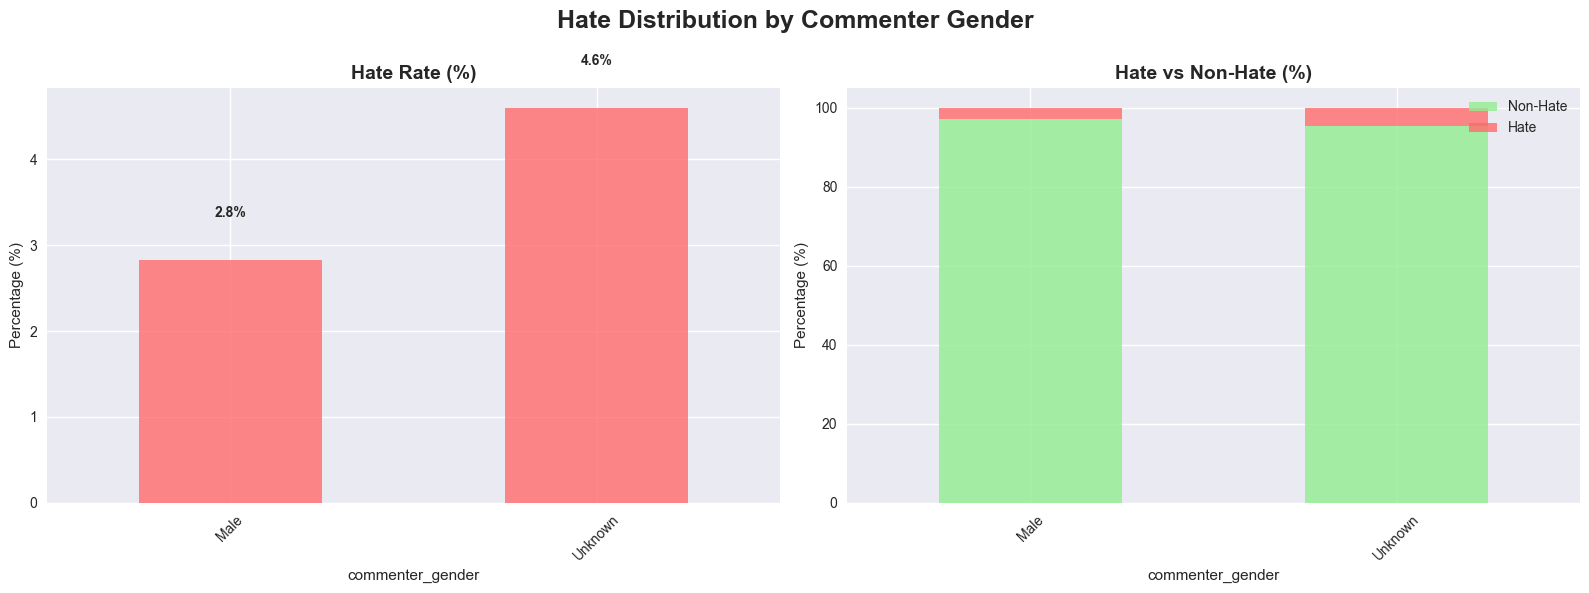


HATE DISTRIBUTION BY COMMENT_LANGUAGE
any_hate              False  True  Hate Rate (%)  Total Comments
comment_language_agg                                            
Other                   308    19       5.810398      332.810398
af                       32     0       0.000000       32.000000
ca                       30     1       3.225806       34.225806
de                       74     3       3.896104       80.896104
en                       30     1       3.225806       34.225806
et                       23     1       4.166667       28.166667
fr                       98     2       2.000000      102.000000
id                       26     1       3.703704       30.703704
no                       24     1       4.000000       29.000000
pt                       35     1       2.777778       38.777778
unknown                 139     1       0.714286      140.714286

📊 Chi-square test:
Chi2 = 9.9148, p = 0.4480
Significant? No


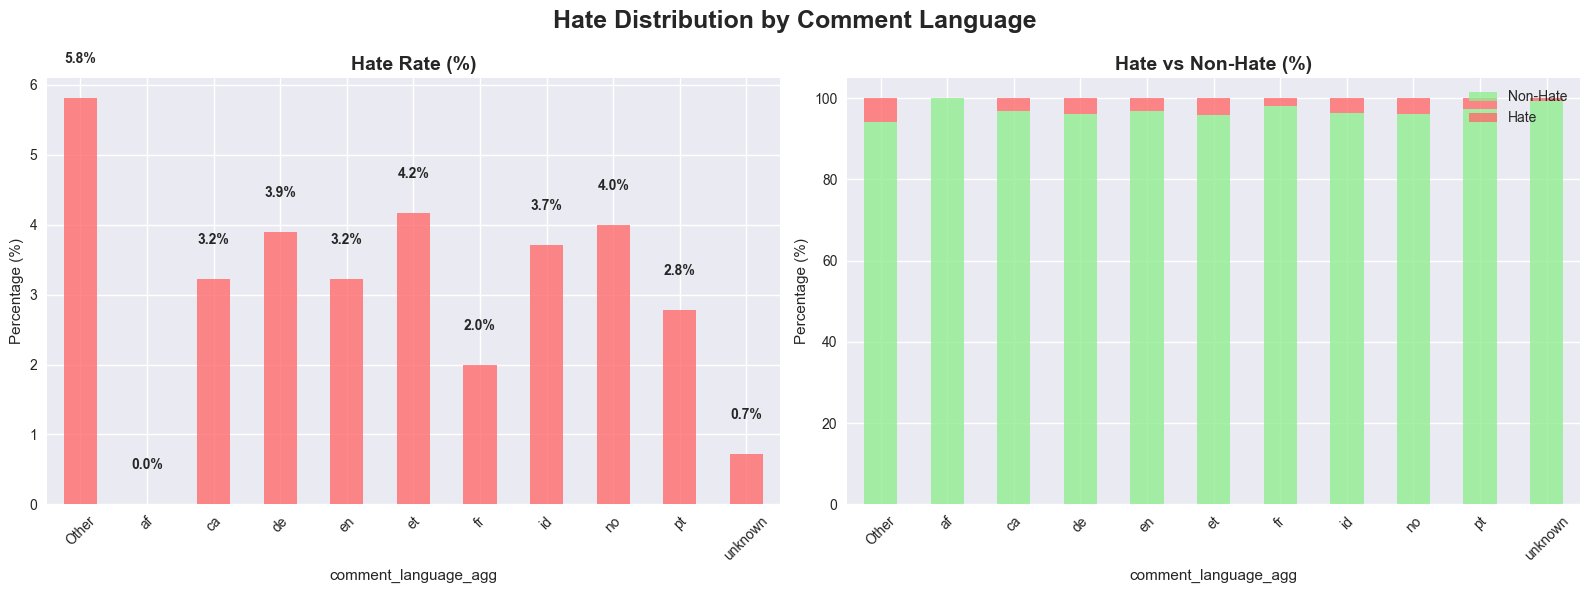


HATE DISTRIBUTION BY CLUB_REGION
any_hate       False  True  Hate Rate (%)  Total Comments
club_region                                              
England          286     7       2.389078      295.389078
France           173     5       2.808989      180.808989
Germany          224     6       2.608696      232.608696
Italy             55     5       8.333333       68.333333
Latin America     81     8       8.988764       97.988764

📊 Chi-square test:
Chi2 = 13.3574, p = 0.0097
Significant? Yes


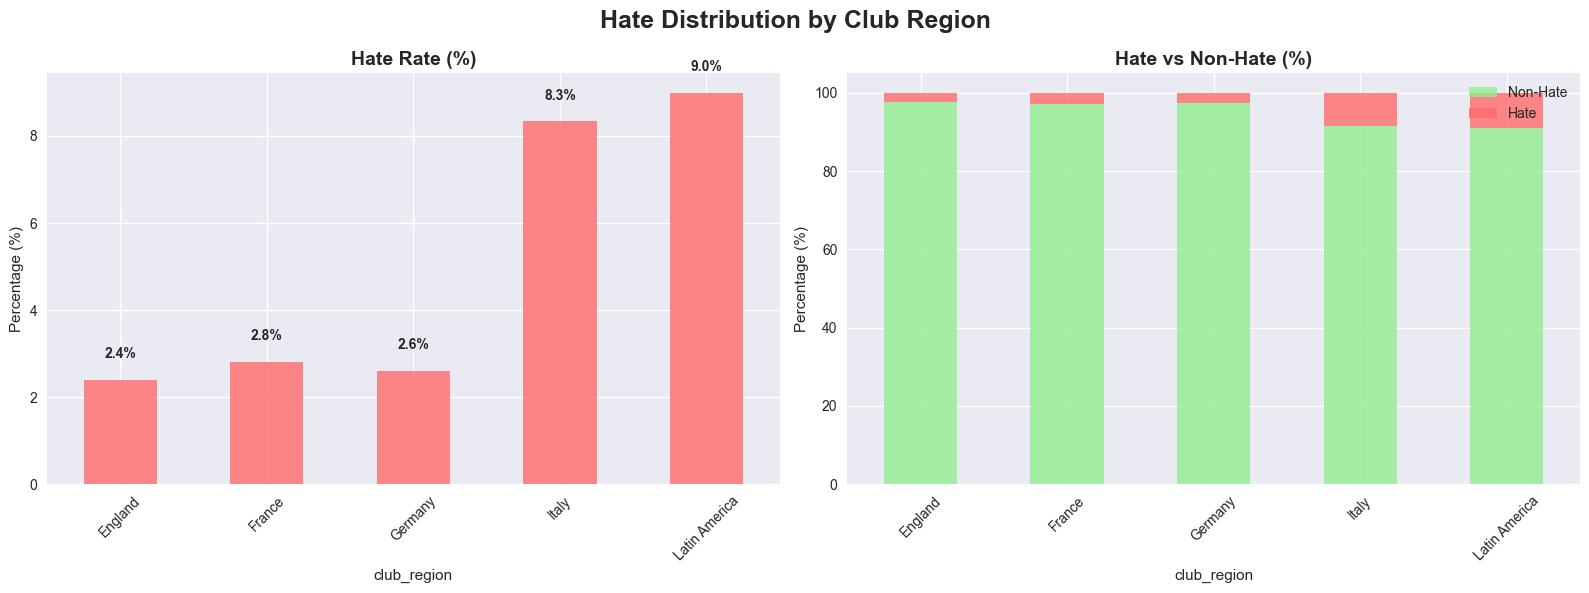


HATE DISTRIBUTION BY CHANNEL_STRUCTURE
any_hate           False  True  Hate Rate (%)  Total Comments
channel_structure                                            
Separate             188    12       6.000000      206.000000
Unified              631    19       2.923077      652.923077

📊 Chi-square test:
Chi2 = 3.2914, p = 0.0696
Significant? No


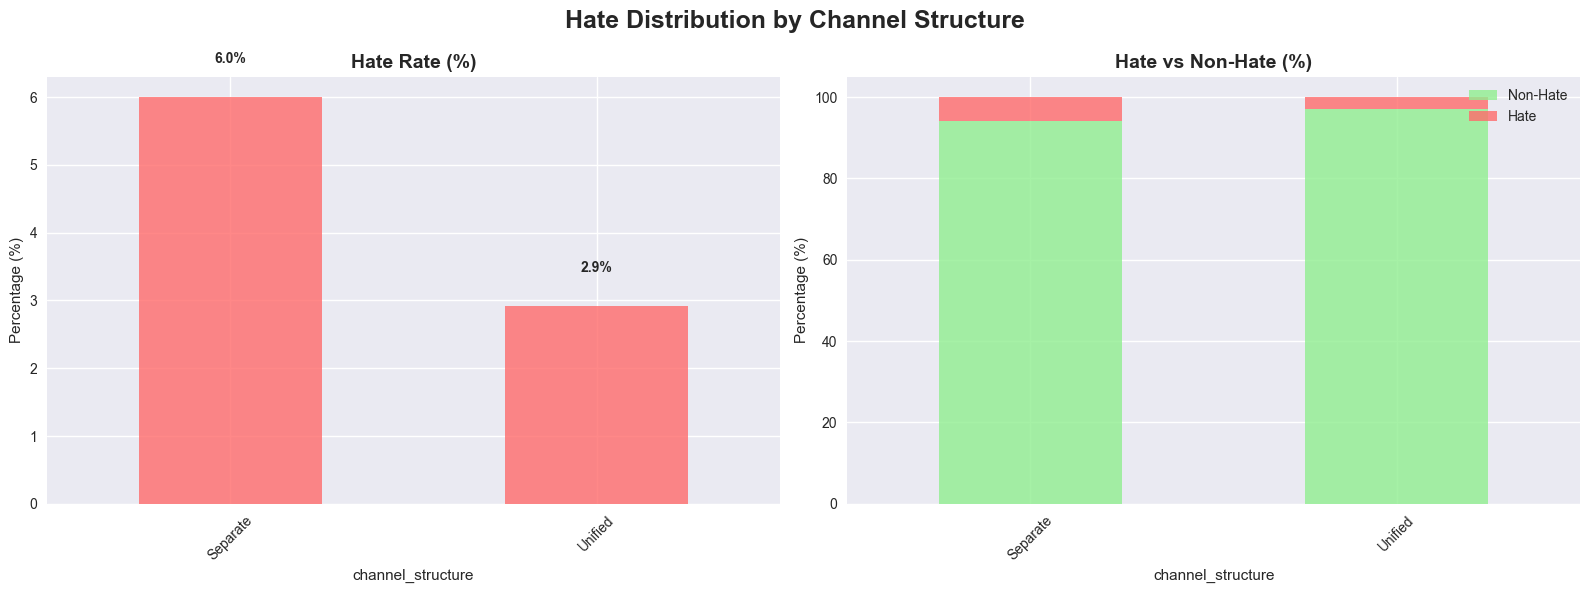

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# LOAD DATA
# -----------------------------------------------------------------------------
df = pd.read_csv("../Datasets/labeled_comments.csv")

# -----------------------------------------------------------------------------
# REBUILD CATEGORICAL VARIABLES
# -----------------------------------------------------------------------------

# --- Commenter Gender ---
df['commenter_gender'] = 'Other'
if 'Commenter Gender_male' in df.columns:
    df.loc[df['Commenter Gender_male'] == 1, 'commenter_gender'] = 'Male'
if 'Commenter Gender_unknown' in df.columns:
    df.loc[df['Commenter Gender_unknown'] == 1, 'commenter_gender'] = 'Unknown'

# --- Comment Language ---
lang_cols = [col for col in df.columns if col.startswith("Language_")]
if lang_cols:
    df['comment_language'] = df[lang_cols].idxmax(axis=1).str.replace("Language_", "")
else:
    df['comment_language'] = "Unknown"

# --- Club Region ---
region_cols = [col for col in df.columns if col.startswith("Club Region_")]
if region_cols:
    df['club_region'] = df[region_cols].idxmax(axis=1).str.replace("Club Region_", "")
else:
    df['club_region'] = "Unknown"

# --- Channel Structure ---
if 'Channel Structure_Seperate' in df.columns and 'Channel Structure_Unified' in df.columns:
    df['channel_structure'] = np.where(df['Channel Structure_Seperate'] == 1, "Separate",
                               np.where(df['Channel Structure_Unified'] == 1, "Unified", "Other"))
else:
    df['channel_structure'] = "Unknown"

# -----------------------------------------------------------------------------
# HATE INDICATORS (already engineered in your earlier script, but ensure exists)
# -----------------------------------------------------------------------------
hate_columns = ['Sexism', 'Racism', 'Violence', 'Appearance', 'Ability']
for col in hate_columns:
    if col not in df.columns:
        df[col] = 0  # fallback if missing

df['sexism_hate'] = df['Sexism'].astype(float) > 0
df['racism_hate'] = df['Racism'].astype(float) > 0
df['violence_hate'] = df['Violence'].astype(float) > 0
df['appearance_hate'] = df['Appearance'].astype(float) > 0
df['ability_hate'] = df['Ability'].astype(float) > 0

df['any_hate'] = (df['sexism_hate'] | df['racism_hate'] |
                  df['violence_hate'] | df['appearance_hate'] | df['ability_hate'])

print(f"✅ Data prepared with {len(df)} comments")

# -----------------------------------------------------------------------------
# ANALYSIS FUNCTION
# -----------------------------------------------------------------------------
def analyze_hate_distribution(df, column, title=None, top_n=10):
    """
    Analyze hate distribution across levels of a given independent variable.
    Aggregates rare categories into 'Other' if more than top_n unique values.
    """
    if column not in df.columns:
        print(f"⚠️ Column '{column}' not found in dataset.")
        return
    
    # Aggregate small categories
    value_counts = df[column].value_counts()
    if len(value_counts) > top_n:
        top_categories = value_counts.nlargest(top_n).index
        df[column + "_agg"] = df[column].where(df[column].isin(top_categories), "Other")
        col_to_use = column + "_agg"
    else:
        col_to_use = column
    
    print("\n" + "="*70)
    print(f"HATE DISTRIBUTION BY {column.upper()}")
    print("="*70)
    
    cross = pd.crosstab(df[col_to_use], df['any_hate'], normalize='index') * 100
    counts = pd.crosstab(df[col_to_use], df['any_hate'])
    
    summary = counts.copy()
    summary['Hate Rate (%)'] = cross[True] if True in cross.columns else 0
    summary['Total Comments'] = summary.sum(axis=1)
    print(summary)
    
    if counts.shape[0] > 1 and counts.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(counts)
        print(f"\n📊 Chi-square test:")
        print(f"Chi2 = {chi2:.4f}, p = {p_value:.4f}")
        print(f"Significant? {'Yes' if p_value < 0.05 else 'No'}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    if title is None:
        title = f"Hate Distribution by {column}"
    
    fig.suptitle(title, fontsize=18, fontweight='bold')
    
    # Hate Rate Barplot
    hate_rates = df.groupby(col_to_use)['any_hate'].mean() * 100
    hate_rates.plot(kind='bar', ax=axes[0], color="#FF6B6B", alpha=0.8)
    axes[0].set_title("Hate Rate (%)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Percentage (%)")
    axes[0].tick_params(axis='x', rotation=45)
    
    for i, v in enumerate(hate_rates):
        axes[0].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')
    
    # Hate vs Non-Hate Stacked Bar
    if not cross.empty:
        cross.plot(kind='bar', stacked=True, ax=axes[1], 
                   color=['#90EE90', '#FF6B6B'], alpha=0.8)
        axes[1].set_title("Hate vs Non-Hate (%)", fontsize=14, fontweight='bold')
        axes[1].set_ylabel("Percentage (%)")
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].legend(['Non-Hate', 'Hate'], loc='upper right')
    
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# RUN ANALYSIS FOR ALL INDEPENDENT VARIABLES
# -----------------------------------------------------------------------------
analyze_hate_distribution(df, "commenter_gender", "Hate Distribution by Commenter Gender")
analyze_hate_distribution(df, "comment_language", "Hate Distribution by Comment Language")
analyze_hate_distribution(df, "club_region", "Hate Distribution by Club Region")
analyze_hate_distribution(df, "channel_structure", "Hate Distribution by Channel Structure")


Dataset Overview:
Shape: (850, 83)
First few column names: ['Unnamed: 0', 'Comment', 'Video Popularity', 'Comment Popularity', 'Gender of Sport_Female', 'Gender of Sport_Male', 'Club_Arsenal', 'Club_Bayern München', 'Club_Chelsea', 'Club_Club América', 'Club_Corinthians', 'Club_Juventus', 'Club_Manchester United', 'Club_Napoli', 'Club_Olympique Lyon']

HATE DISTRIBUTION BY COMMENTER_GENDER
any_hate          False  True  Hate Rate (%)  Total Comments
commenter_gender                                            
Male                446    13       2.832244      461.832244
Unknown             373    18       4.603581      395.603581

📊 Chi-square test:
Chi2 = 1.4149, p = 0.2343
Significant? No


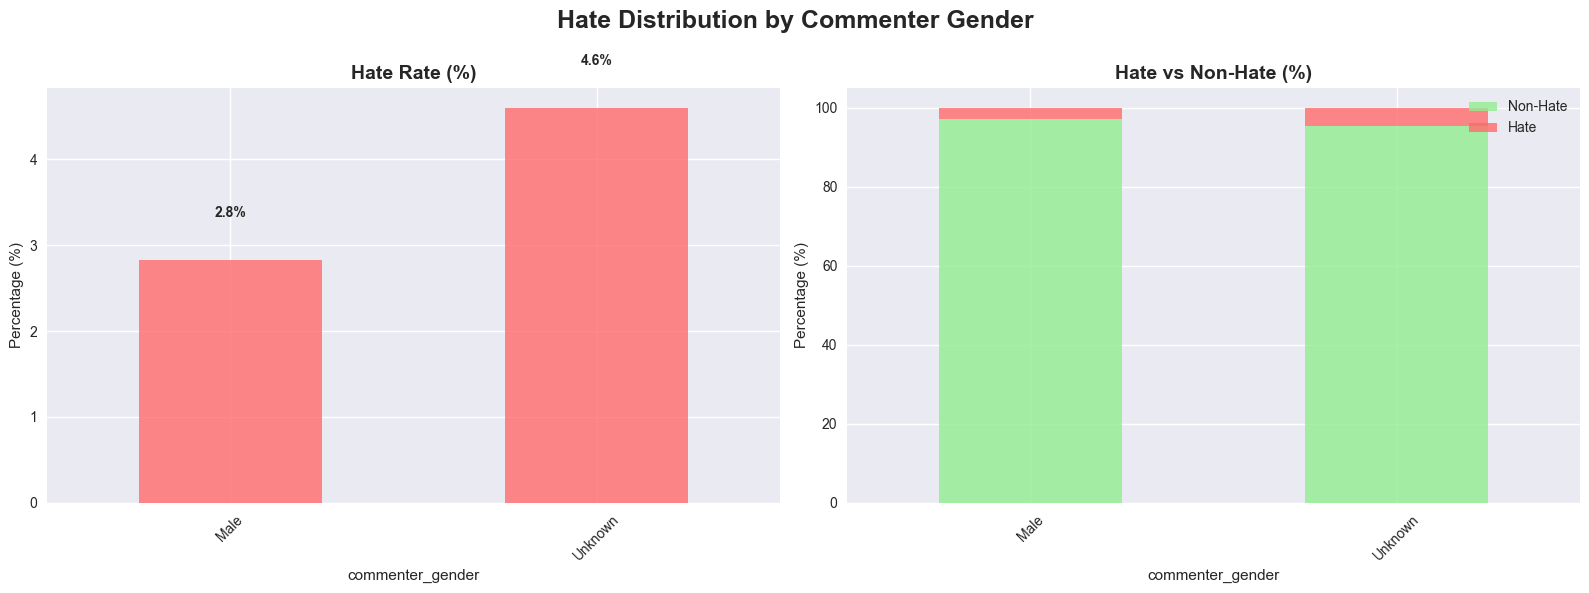


HATE DISTRIBUTION BY COMMENT_LANGUAGE
any_hate          False  True  Hate Rate (%)  Total Comments
comment_language                                            
af                   32     0       0.000000       32.000000
ar                    7     1      12.500000       20.500000
bg                    3     0       0.000000        3.000000
ca                   30     1       3.225806       34.225806
cs                    7     0       0.000000        7.000000
cy                   17     0       0.000000       17.000000
da                   13     1       7.142857       21.142857
de                   74     3       3.896104       80.896104
el                    2     1      33.333333       36.333333
en                   30     1       3.225806       34.225806
es                   10     3      23.076923       36.076923
et                   23     1       4.166667       28.166667
fa                    4     0       0.000000        4.000000
fi                   23     1       4.166667  

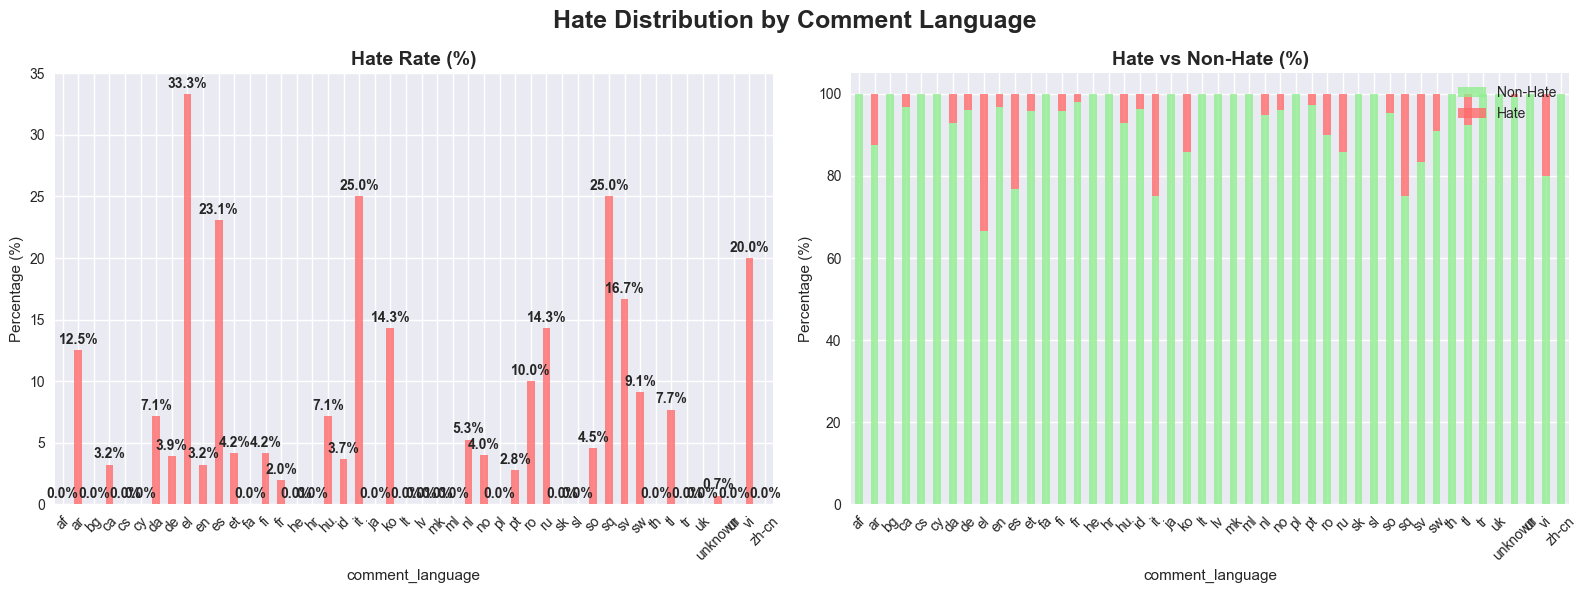


HATE DISTRIBUTION BY CLUB_REGION
any_hate       False  True  Hate Rate (%)  Total Comments
club_region                                              
England          286     7       2.389078      295.389078
France           173     5       2.808989      180.808989
Germany          224     6       2.608696      232.608696
Italy             55     5       8.333333       68.333333
Latin America     81     8       8.988764       97.988764

📊 Chi-square test:
Chi2 = 13.3574, p = 0.0097
Significant? Yes


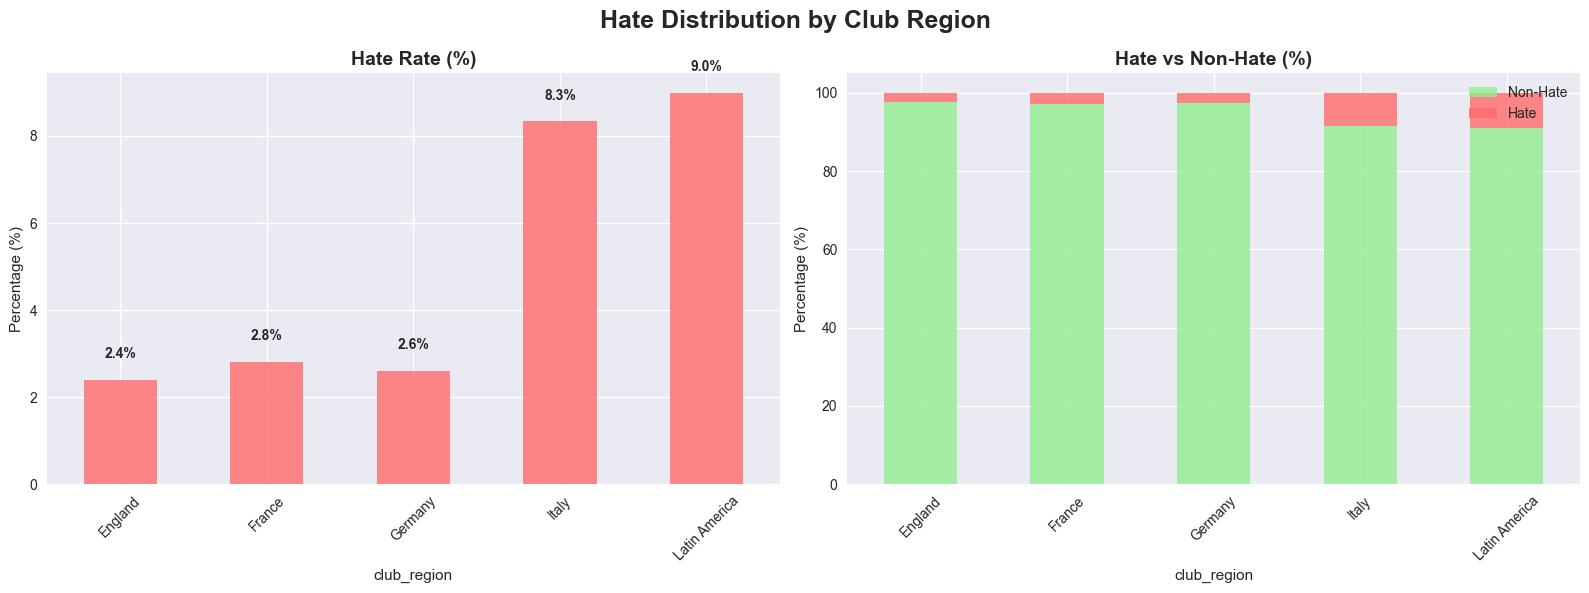


HATE DISTRIBUTION BY CHANNEL_STRUCTURE
any_hate           False  True  Hate Rate (%)  Total Comments
channel_structure                                            
Separate             188    12       6.000000      206.000000
Unified              631    19       2.923077      652.923077

📊 Chi-square test:
Chi2 = 3.2914, p = 0.0696
Significant? No


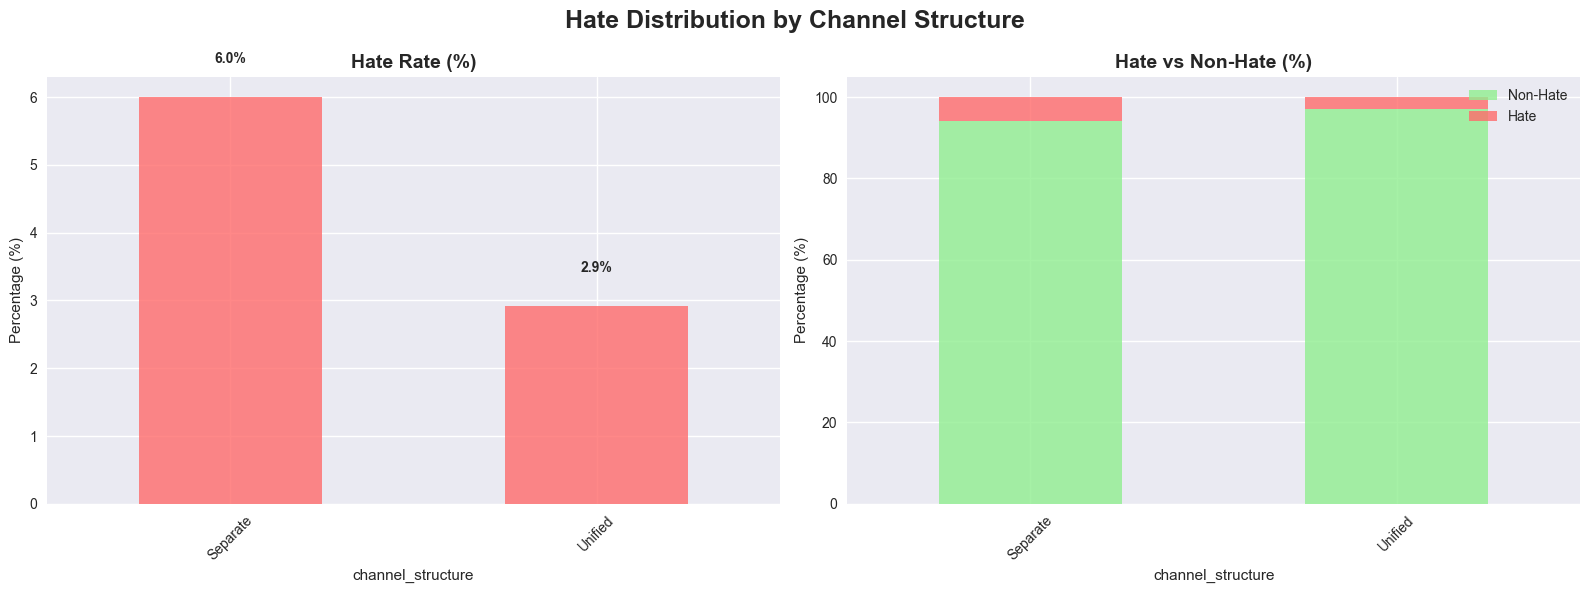


HATE DISTRIBUTION BY CHANNEL STRUCTURE × GENDER OF SPORT
any_hate                        False  True  Hate Rate (%)  Total Comments
gender_sport channel_structure                                            
Female       Separate              73     4       5.194805       82.194805
             Unified              209    10       4.566210      223.566210
Male         Separate             115     8       6.504065      129.504065
             Unified              422     9       2.088167      433.088167

📊 Chi-square test:
Chi2 = 6.8891, p = 0.0755
Significant? No


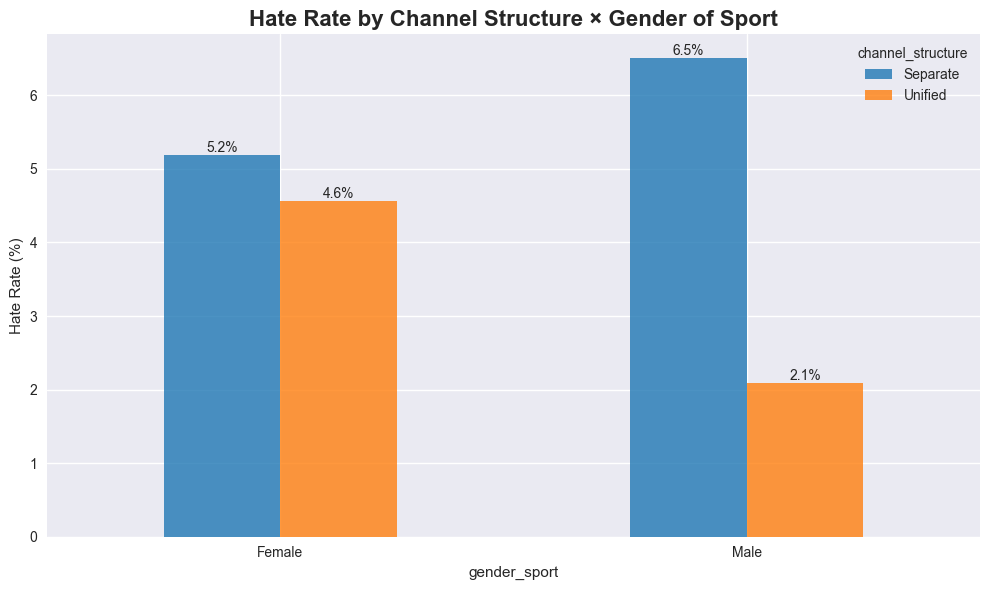


HATE DISTRIBUTION BY VIDEO POPULARITY
any_hate              False  True  Hate Rate (%)  Total Comments
Video Popularity_bin                                            
(-0.001, 1.0]           654    21       3.111111      678.111111
(1.0, 2.0]              165    10       5.714286      180.714286

📊 Chi-square test:
Chi2 = 1.9903, p = 0.1583
Significant? No


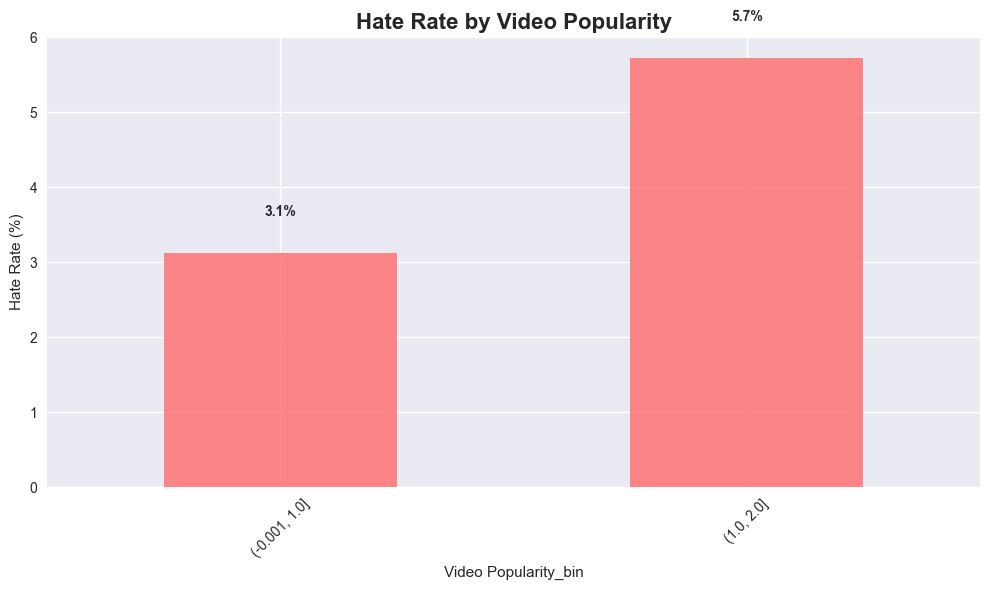


HATE DISTRIBUTION BY COMMENT POPULARITY
any_hate                False  True  Hate Rate (%)  Total Comments
Comment Popularity_bin                                            
(-0.001, 1.0]             386    21       5.159705      412.159705
(1.0, 2.0]                433    10       2.257336      445.257336

📊 Chi-square test:
Chi2 = 4.2924, p = 0.0383
Significant? Yes


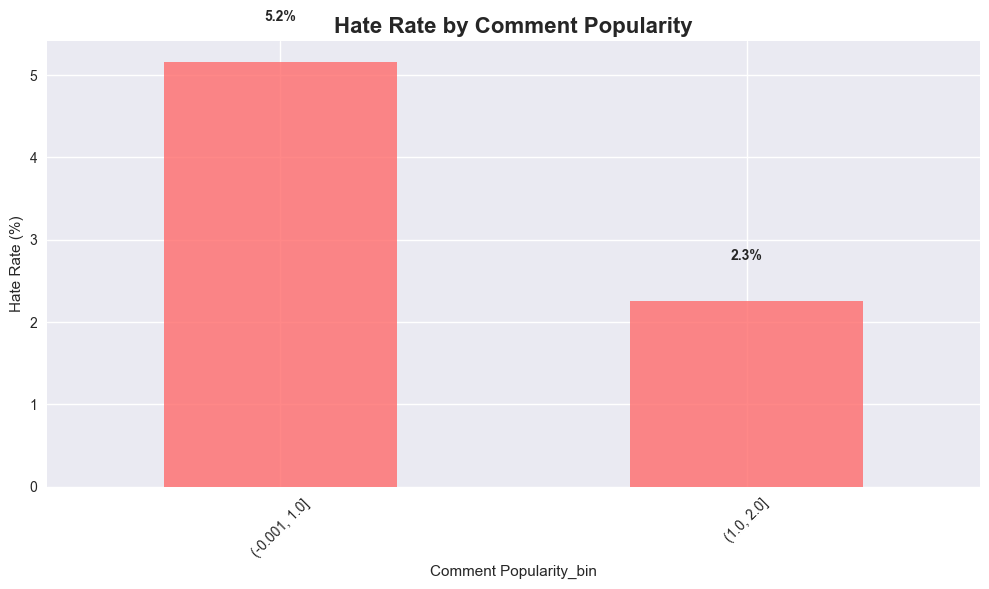

In [17]:
# =============================================================================
# IMPORTS & SETUP
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# LOAD DATA
# =============================================================================
df = pd.read_csv('../Datasets/labeled_comments.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"First few column names: {df.columns.tolist()[:15]}")

# =============================================================================
# FEATURE ENGINEERING
# =============================================================================
# --- Gender of Sport ---
df['gender_sport'] = 'Unknown'
if 'Gender of Sport_Female' in df.columns:
    df.loc[df['Gender of Sport_Female'] == 1, 'gender_sport'] = 'Female'
if 'Gender of Sport_Male' in df.columns:
    df.loc[df['Gender of Sport_Male'] == 1, 'gender_sport'] = 'Male'

# --- Commenter Gender ---
df['commenter_gender'] = 'Other'
if 'Commenter Gender_male' in df.columns:
    df.loc[df['Commenter Gender_male'] == 1, 'commenter_gender'] = 'Male'
if 'Commenter Gender_unknown' in df.columns:
    df.loc[df['Commenter Gender_unknown'] == 1, 'commenter_gender'] = 'Unknown'

# --- Comment Language ---
lang_cols = [col for col in df.columns if col.startswith("Language_")]
if lang_cols:
    df['comment_language'] = df[lang_cols].idxmax(axis=1).str.replace("Language_", "")
else:
    df['comment_language'] = "Unknown"

# --- Club Region ---
region_cols = [col for col in df.columns if col.startswith("Club Region_")]
if region_cols:
    df['club_region'] = df[region_cols].idxmax(axis=1).str.replace("Club Region_", "")
else:
    df['club_region'] = "Unknown"

# --- Channel Structure ---
if 'Channel Structure_Seperate' in df.columns and 'Channel Structure_Unified' in df.columns:
    df['channel_structure'] = np.where(df['Channel Structure_Seperate'] == 1, "Separate",
                               np.where(df['Channel Structure_Unified'] == 1, "Unified", "Other"))
else:
    df['channel_structure'] = "Other"

# --- Hate Columns ---
def convert_hate_column(col_series):
    result = []
    for val in col_series:
        if pd.isna(val) or val == '' or val == ' ':
            result.append(False)
        else:
            try:
                result.append(float(val) > 0)
            except (ValueError, TypeError):
                result.append(False)
    return result

hate_columns = ['Sexism', 'Racism', 'Violence', 'Appearance', 'Ability']
for col in hate_columns:
    if col in df.columns:
        df[f'{col.lower()}_hate'] = convert_hate_column(df[col])
    else:
        df[f'{col.lower()}_hate'] = False

df['any_hate'] = (df['sexism_hate'] | df['racism_hate'] | df['violence_hate'] |
                  df['appearance_hate'] | df['ability_hate'])

# =============================================================================
# FUNCTIONS
# =============================================================================
def analyze_hate_distribution(df, column, title=None):
    """Generic hate distribution analysis for a single categorical variable"""
    if column not in df.columns:
        print(f"⚠️ Column '{column}' not found.")
        return
    
    print("\n" + "="*70)
    print(f"HATE DISTRIBUTION BY {column.upper()}")
    print("="*70)
    
    cross = pd.crosstab(df[column], df['any_hate'], normalize='index') * 100
    counts = pd.crosstab(df[column], df['any_hate'])
    
    summary = counts.copy()
    summary['Hate Rate (%)'] = cross[True] if True in cross.columns else 0
    summary['Total Comments'] = summary.sum(axis=1)
    print(summary)
    
    if counts.shape[0] > 1 and counts.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(counts)
        print(f"\n📊 Chi-square test:")
        print(f"Chi2 = {chi2:.4f}, p = {p_value:.4f}")
        print(f"Significant? {'Yes' if p_value < 0.05 else 'No'}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    if title is None:
        title = f"Hate Distribution by {column}"
    fig.suptitle(title, fontsize=18, fontweight='bold')
    
    hate_rates = df.groupby(column)['any_hate'].mean() * 100
    hate_rates.plot(kind='bar', ax=axes[0], color="#FF6B6B", alpha=0.8)
    axes[0].set_title("Hate Rate (%)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Percentage (%)")
    axes[0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(hate_rates):
        axes[0].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')
    
    if not cross.empty:
        cross.plot(kind='bar', stacked=True, ax=axes[1], 
                   color=['#90EE90', '#FF6B6B'], alpha=0.8)
        axes[1].set_title("Hate vs Non-Hate (%)", fontsize=14, fontweight='bold')
        axes[1].set_ylabel("Percentage (%)")
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].legend(['Non-Hate', 'Hate'], loc='upper right')
    
    plt.tight_layout()
    plt.show()


def analyze_channel_structure_by_gender(df):
    """Special: Channel structure × Gender of Sport"""
    print("\n" + "="*70)
    print("HATE DISTRIBUTION BY CHANNEL STRUCTURE × GENDER OF SPORT")
    print("="*70)

    cross = pd.crosstab([df['gender_sport'], df['channel_structure']], df['any_hate'], normalize='index') * 100
    counts = pd.crosstab([df['gender_sport'], df['channel_structure']], df['any_hate'])

    summary = counts.copy()
    summary['Hate Rate (%)'] = cross[True] if True in cross.columns else 0
    summary['Total Comments'] = summary.sum(axis=1)
    print(summary)

    if counts.shape[0] > 1 and counts.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(counts)
        print(f"\n📊 Chi-square test:")
        print(f"Chi2 = {chi2:.4f}, p = {p_value:.4f}")
        print(f"Significant? {'Yes' if p_value < 0.05 else 'No'}")

    fig, ax = plt.subplots(figsize=(10, 6))
    hate_rates = df.groupby(['gender_sport','channel_structure'])['any_hate'].mean() * 100
    hate_rates.unstack().plot(kind='bar', ax=ax, alpha=0.8, color=['#1f77b4','#ff7f0e'])

    ax.set_title("Hate Rate by Channel Structure × Gender of Sport", fontsize=16, fontweight='bold')
    ax.set_ylabel("Hate Rate (%)")
    ax.tick_params(axis='x', rotation=0)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", label_type="edge", fontsize=10)

    plt.tight_layout()
    plt.show()


def analyze_popularity(df, col, bins=5):
    """Analyze numeric popularity variables (Video, Comment)"""
    print("\n" + "="*70)
    print(f"HATE DISTRIBUTION BY {col.upper()}")
    print("="*70)

    df[col + '_bin'] = pd.qcut(df[col], q=bins, duplicates='drop')

    cross = pd.crosstab(df[col + '_bin'], df['any_hate'], normalize='index') * 100
    counts = pd.crosstab(df[col + '_bin'], df['any_hate'])

    summary = counts.copy()
    summary['Hate Rate (%)'] = cross[True] if True in cross.columns else 0
    summary['Total Comments'] = summary.sum(axis=1)
    print(summary)

    if counts.shape[0] > 1 and counts.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(counts)
        print(f"\n📊 Chi-square test:")
        print(f"Chi2 = {chi2:.4f}, p = {p_value:.4f}")
        print(f"Significant? {'Yes' if p_value < 0.05 else 'No'}")

    fig, ax = plt.subplots(figsize=(10, 6))
    hate_rates = df.groupby(col + '_bin')['any_hate'].mean() * 100
    hate_rates.plot(kind='bar', ax=ax, color="#FF6B6B", alpha=0.8)

    ax.set_title(f"Hate Rate by {col}", fontsize=16, fontweight='bold')
    ax.set_ylabel("Hate Rate (%)")
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(hate_rates):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# =============================================================================
# RUN ANALYSIS
# =============================================================================
# Generic independent variable distributions
analyze_hate_distribution(df, "commenter_gender", "Hate Distribution by Commenter Gender")
analyze_hate_distribution(df, "comment_language", "Hate Distribution by Comment Language")
analyze_hate_distribution(df, "club_region", "Hate Distribution by Club Region")
analyze_hate_distribution(df, "channel_structure", "Hate Distribution by Channel Structure")

# Special: Channel Structure × Gender of Sport
analyze_channel_structure_by_gender(df)

# Popularity variables
if "Video Popularity" in df.columns:
    analyze_popularity(df, "Video Popularity", bins=5)

if "Comment Popularity" in df.columns:
    analyze_popularity(df, "Comment Popularity", bins=5)
